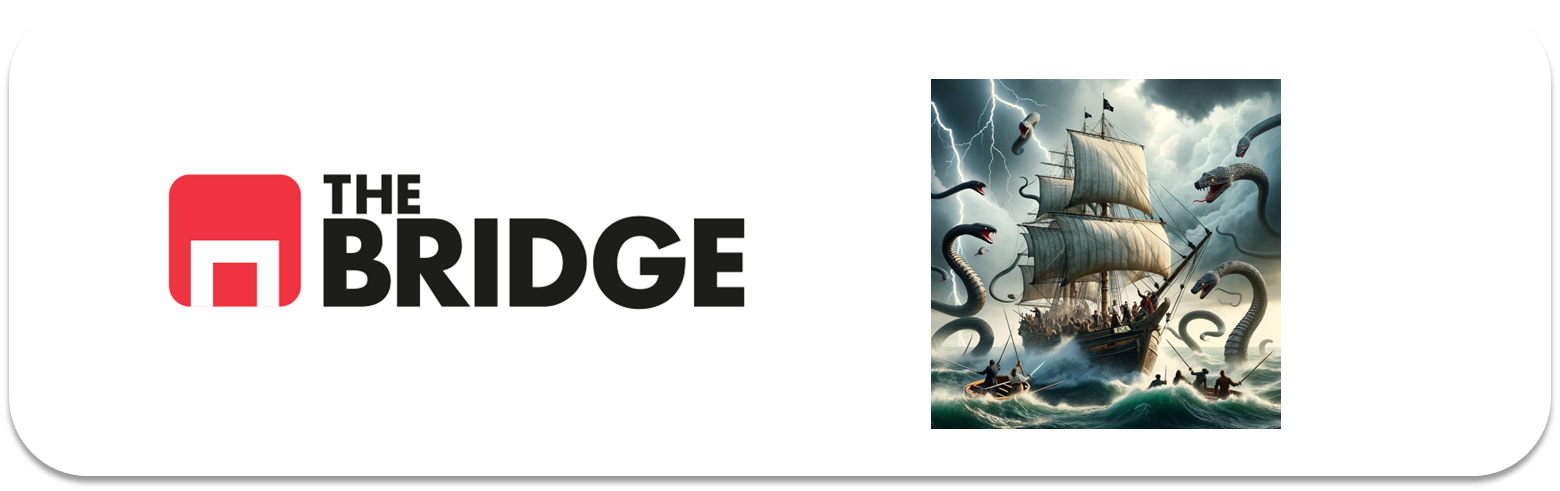

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


In [2]:
df = pd.read_csv("credit_npo.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), int64(7)
me

In [3]:
df = df.drop("MonthlyIncome", axis = 1)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 10 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 6   NumberOfTimes90DaysLate               12537 non-null  int64  
 7   NumberRealEstateLoansOrLines          12537 non-null  int64  
 8   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 9   NumberOfDependents                    12360 non-null  float64
dtypes: float64(3), int64(7)
memory usage: 979.6 KB


In [4]:
df = df.drop("NumberOfDependents", axis = 1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 9 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 6   NumberOfTimes90DaysLate               12537 non-null  int64  
 7   NumberRealEstateLoansOrLines          12537 non-null  int64  
 8   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 881.6 KB


In [5]:
# Básicos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Selección de features
from sklearn.feature_selection import (
    SelectKBest,
    f_classif,          # ANOVA para numéricas
    mutual_info_classif, # Mutual Information para categóricas
    SelectFromModel,
    RFE,
    SequentialFeatureSelector as SFS
)

# Modelos (para SelectFromModel, RFE, SFS y la comparación final)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

# Preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate

# Optimización
from sklearn.model_selection import RandomizedSearchCV

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

   SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0                 0                              0.081892   37   
1                 0                              0.023413   74   
2                 0                              0.000000   43   
3                 0                              0.492754   44   
4                 0                              1.000000   63   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  \
0                                     0   0.070709   
1                                     0   0.209197   
2                                     0   0.080784   
3                                     0   0.412735   
4                                     0   0.000000   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               12                        1   
1                                9                        0   
2                                2                        0   
3                         

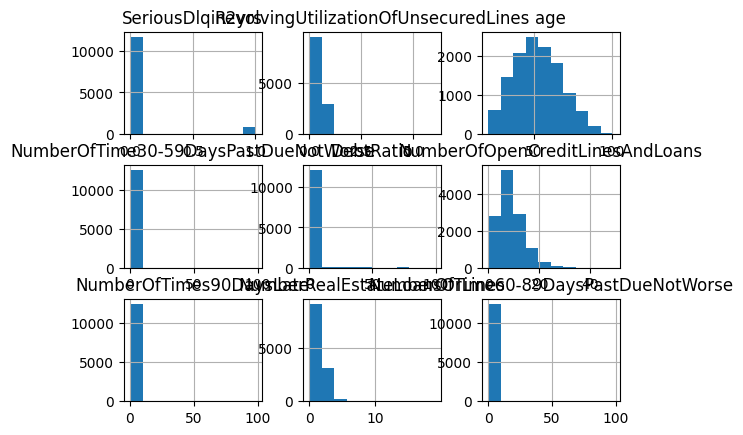

In [6]:
print(df.head())
print(df.hist())

In [7]:
cols_number = [col for col in df.columns if col.startswith('NumberOf')]
for col in cols_number:
    print(f"{col}: {sorted(df[col].unique())}")


NumberOfTime30-59DaysPastDueNotWorse: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(98)]
NumberOfOpenCreditLinesAndLoans: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(38), np.int64(40), np.int64(41), np.int64(43), np.int64(48), np.int64(49)]
NumberOfTimes90DaysLate: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(13), np.int64(98)]
Number

In [8]:
# Las tres columnas de retraso → 3 niveles
cols_retraso = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

for col in cols_retraso:
    df[col] = df[col].apply(lambda x: 2 if x >= 2 else x)  # 98 → 2, resto igual
    df[col] = df[col].astype('category')

# Verificar
for col in cols_retraso:
    print(f"{col}: {df[col].value_counts().sort_index()}")

NumberOfTime30-59DaysPastDueNotWorse: NumberOfTime30-59DaysPastDueNotWorse
0    10500
1     1377
2      660
Name: count, dtype: int64
NumberOfTimes90DaysLate: NumberOfTimes90DaysLate
0    11839
1      412
2      286
Name: count, dtype: int64
NumberOfTime60-89DaysPastDueNotWorse: NumberOfTime60-89DaysPastDueNotWorse
0    11901
1      492
2      144
Name: count, dtype: int64


In [10]:
#Escalamos la sexta del histograma
scaler = StandardScaler()
df[['NumberOfOpenCreditLinesAndLoans']] = scaler.fit_transform(df[['NumberOfOpenCreditLinesAndLoans']])

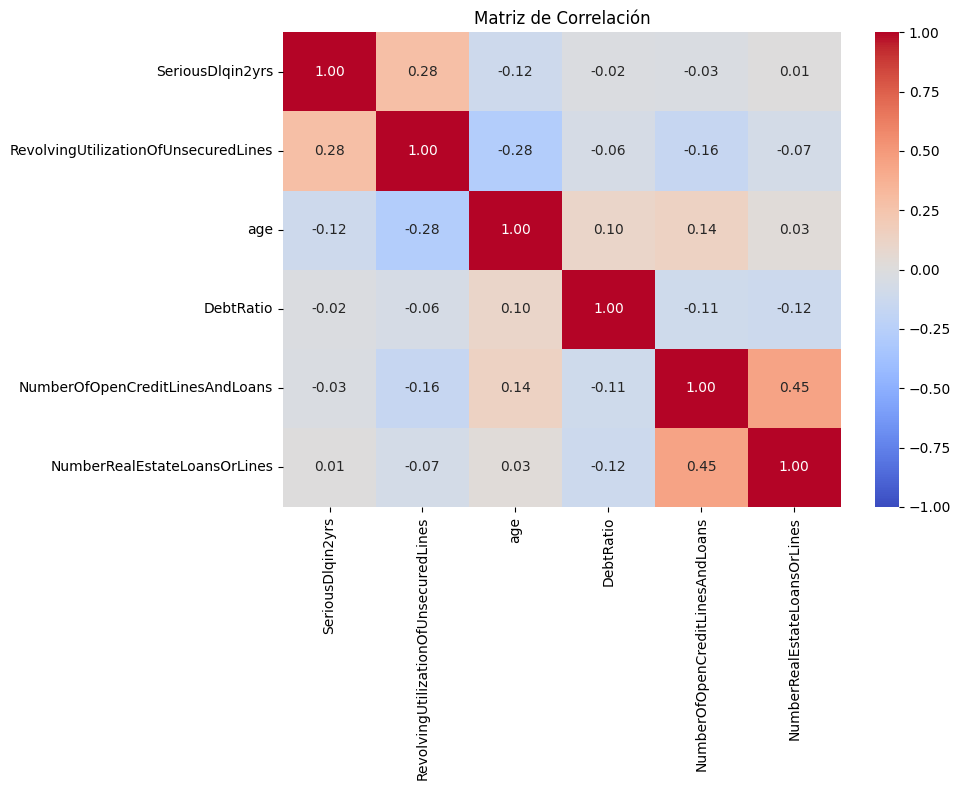

In [11]:
# Matriz de correlación solo con numéricas
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

In [12]:
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (10029, 8), Test: (2508, 8)


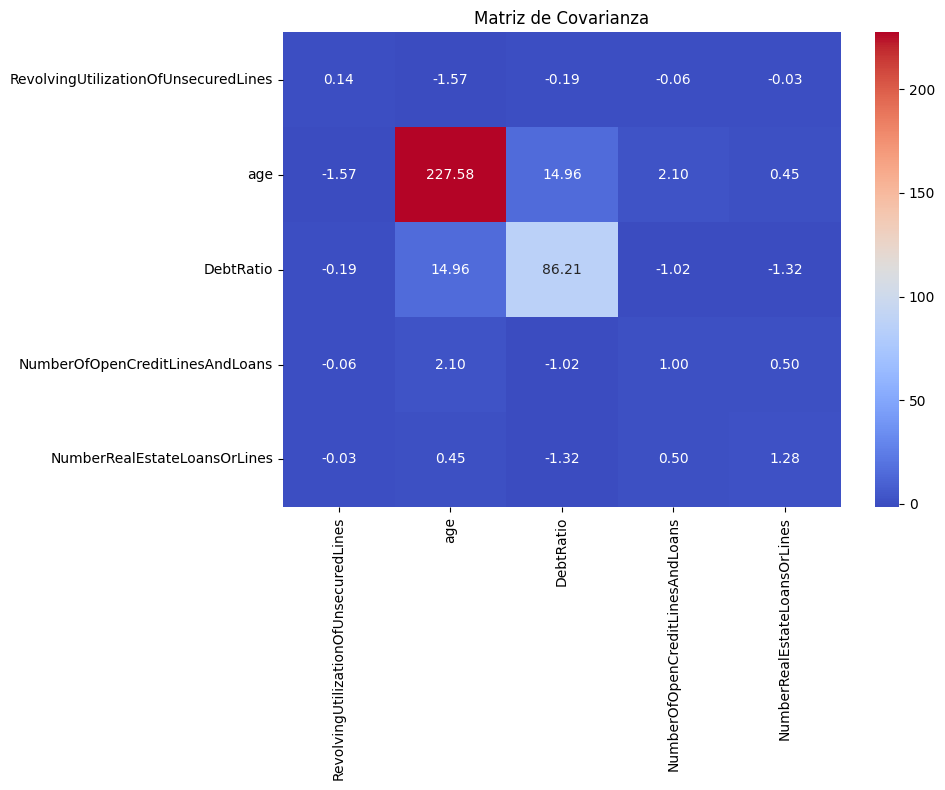

In [13]:
# Matriz de covarianza (solo numéricas)
cov_matrix = X_train.select_dtypes(include='number').cov()

plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Covarianza')
plt.tight_layout()
plt.show()

In [14]:
# ══════════════════════════════════════════════════════════════
# PASO 2.2 — SelectKBest
# ══════════════════════════════════════════════════════════════

# Separamos las columnas numéricas de las categóricas
# porque cada método de selección funciona con un tipo distinto
cols_numericas   = X_train.select_dtypes(include='number').columns.tolist()
cols_categoricas = X_train.select_dtypes(include='category').columns.tolist()

print("Numéricas:", cols_numericas)
print("Categóricas:", cols_categoricas)

# ── NUMÉRICAS: SelectKBest con ANOVA (f_classif) ──────────────
# ANOVA mide si la media de cada feature es distinta entre clases
# Si las medias son muy distintas → la feature es útil para separar clases
# f_classif solo funciona con variables numéricas continuas

selector_num = SelectKBest(score_func=f_classif, k='all')  # k='all' para ver todos los scores
selector_num.fit(X_train[cols_numericas], y_train)

# Ver los scores de cada feature numérica
scores_num = pd.DataFrame({
    'Feature': cols_numericas,
    'Score':   selector_num.scores_,
    'P-value': selector_num.pvalues_
}).sort_values('Score', ascending=False)

print("\n--- Scores ANOVA (numéricas) ---")
print(scores_num)

# ── CATEGÓRICAS: SelectKBest con Mutual Information ───────────
# Mutual Information mide cuánta información aporta una feature sobre el target
# Funciona con cualquier tipo de variable (numérica o categórica)
# 0 = independientes, >0 = tienen relación

# Convertir categóricas a int para que sklearn las acepte
X_train_cat = X_train[cols_categoricas].apply(lambda x: x.cat.codes)

selector_cat = SelectKBest(score_func=mutual_info_classif, k='all')
selector_cat.fit(X_train_cat, y_train)

scores_cat = pd.DataFrame({
    'Feature': cols_categoricas,
    'Score':   selector_cat.scores_
}).sort_values('Score', ascending=False)

print("\n--- Scores Mutual Information (categóricas) ---")
print(scores_cat)

Numéricas: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines']
Categóricas: ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']

--- Scores ANOVA (numéricas) ---
                                Feature       Score        P-value
0  RevolvingUtilizationOfUnsecuredLines  857.968250  4.902310e-181
1                                   age  135.641398   3.791359e-31
3       NumberOfOpenCreditLinesAndLoans    9.804063   1.746272e-03
2                             DebtRatio    4.209867   4.021541e-02
4          NumberRealEstateLoansOrLines    0.012805   9.099055e-01

--- Scores Mutual Information (categóricas) ---
                                Feature     Score
1               NumberOfTimes90DaysLate  0.035094
0  NumberOfTime30-59DaysPastDueNotWorse  0.026585
2  NumberOfTime60-89DaysPastDueNotWorse  0.019463


In [ ]:
# ══════════════════════════════════════════════════════════════
# PASO 2.3 — SelectFromModel
# ══════════════════════════════════════════════════════════════

# SelectFromModel entrena un modelo internamente y selecciona las features
# que superen un umbral de importancia
# Usamos RandomForest porque maneja bien tanto numéricas como categóricas

from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# Primero preparamos X_train con las categóricas convertidas a int
# (sklearn no acepta dtype 'category' directamente)
X_train_encoded = X_train.copy()
for col in cols_categoricas:
    X_train_encoded[col] = X_train_encoded[col].cat.codes

X_test_encoded = X_test.copy()
for col in cols_categoricas:
    X_test_encoded[col] = X_test_encoded[col].cat.codes

# Instanciar el modelo intermedio
# No necesita ser el mejor modelo, solo sirve para puntuar las features
modelo_intermedio = RandomForestClassifier(n_estimators=100, random_state=42)

# SelectFromModel entrena el modelo y selecciona las features
# cuya importancia supera la media (threshold='mean')
selector_sfm = SelectFromModel(modelo_intermedio, threshold='mean', max_features=6)
selector_sfm.fit(X_train_encoded, y_train)

# Ver qué features seleccionó
features_lista_3 = X_train_encoded.columns[selector_sfm.get_support()].tolist()
print("Lista 3 — SelectFromModel:", features_lista_3)

# Ver las importancias de todas las features para entender la selección
importancias = pd.DataFrame({
    'Feature':    X_train_encoded.columns,
    'Importancia': selector_sfm.estimator_.feature_importances_
}).sort_values('Importancia', ascending=False)
print(importancias)


# ══════════════════════════════════════════════════════════════
# PASO 2.4 — RFE (Recursive Feature Elimination)
# ══════════════════════════════════════════════════════════════

# RFE elimina features de forma recursiva:
# 1. Entrena el modelo con todas las features
# 2. Elimina la menos importante
# 3. Repite hasta quedarse con n_features_to_select

from sklearn.feature_selection import RFE

modelo_rfe = RandomForestClassifier(n_estimators=100, random_state=42)

# n_features_to_select = máximo 6 según el enunciado
selector_rfe = RFE(estimator=modelo_rfe, n_features_to_select=6)
selector_rfe.fit(X_train_encoded, y_train)

# Ver qué features seleccionó y en qué orden fueron eliminadas
features_lista_4 = X_train_encoded.columns[selector_rfe.get_support()].tolist()
print("\nLista 4 — RFE:", features_lista_4)

ranking_rfe = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Ranking': selector_rfe.ranking_   # 1 = seleccionada, >1 = eliminada
}).sort_values('Ranking')
print(ranking_rfe)


# ══════════════════════════════════════════════════════════════
# PASO 2.5 — SFS (Sequential Feature Selection)
# ══════════════════════════════════════════════════════════════

# SFS añade (o elimina) features una a una buscando la combinación
# que maximiza el rendimiento del modelo en validación cruzada
# direction='forward' → empieza vacío y va añadiendo la mejor feature cada vez

from sklearn.feature_selection import SequentialFeatureSelector as SFS

modelo_sfs = RandomForestClassifier(n_estimators=100, random_state=42)

selector_sfs = SFS(
    estimator=modelo_sfs,
    n_features_to_select=6,    # Máximo 6
    direction='forward',        # Añade features de una en una
    scoring='recall_macro',     # Métrica que usamos para evaluar cada combinación
    cv=3,                       # 3 folds para que no tarde demasiado
    n_jobs=-1                   # Usar todos los cores
)
selector_sfs.fit(X_train_encoded, y_train)

features_lista_5 = X_train_encoded.columns[selector_sfs.get_support()].tolist()
print("\nLista 5 — SFS:", features_lista_5)


# ══════════════════════════════════════════════════════════════
# PASO 2.6 — Hard Voting entre las 5 listas
# ══════════════════════════════════════════════════════════════

# Hard voting: una feature entra en la lista final si aparece
# en al menos la mitad de las listas anteriores (mayoría)

from collections import Counter

# Juntamos todas las listas
todas_las_listas = [
    features_lista_1,
    features_lista_2,
    features_lista_3,
    features_lista_4,
    features_lista_5
]

# Contamos cuántas veces aparece cada feature
votos = Counter(f for lista in todas_las_listas for f in lista)
print("\nVotos por feature:")
for feature, n_votos in votos.most_common():
    print(f"  {feature}: {n_votos}/5 listas")

# Una feature entra si aparece en 3 o más listas (mayoría simple)
# Si con umbral 3 obtienes más de 6, subimos a 4
umbral_votos = 3
features_lista_6 = [f for f, v in votos.items() if v >= umbral_votos]

# Si hay más de 6, nos quedamos con las más votadas
if len(features_lista_6) > 6:
    features_lista_6 = [f for f, v in votos.most_common(6)]

print("\nLista 6 — Hard Voting:", features_lista_6)


# ══════════════════════════════════════════════════════════════
# RESUMEN DE LAS 6 LISTAS
# ══════════════════════════════════════════════════════════════

listas = {
    'Lista 2 (SelectKBest)':            selector_cat,
    'Lista 3 (SelectFromModel)':        features_lista_3,
    'Lista 4 (RFE)':                    features_lista_4,
    'Lista 5 (SFS)':                    features_lista_5,
    'Lista 6 (Hard Voting)':            features_lista_6
}

for nombre, lista in listas.items():
    print(f"{nombre} ({len(lista)} features): {lista}")

In [ ]:
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier)
from lightgbm import LGBMClassifier
rnd_clf  = RandomForestClassifier(n_estimators=100, random_state=42)
lgb_clf =  LGBMClassifier(n_estimators=100, random_state = 42)
gb_clf = GradientBoostingClassifier(n_estimators=100,random_state = 42)
scoring_clf = {
    'Accuracy':  'accuracy',
    'Precision': 'precision_macro',
    'Recall':    'recall_macro',  
    'F1':        'f1_macro'
}
rf_cv   = cross_validate(rnd_clf,  X_train_encoded,        y_train, cv=5, scoring=scoring_clf)
lgbm_cv = cross_validate(lgb_clf, X_train_encoded,        y_train, cv=5, scoring=scoring_clf)
gb_cv  = cross_validate(gb_clf, X_train_encoded, y_train, cv=5, scoring=scoring_clf)
# Ver resultados
print('--- Random Forest ---')
print(f'Accuracy:  {rf_cv["test_Accuracy"].mean():.4f} ± {rf_cv["test_Accuracy"].std():.4f}')
print(f'Recall:    {rf_cv["test_Recall"].mean():.4f}')
print('--- LightBM ---')
print(f'Accuracy:  {lgbm_cv["test_Accuracy"].mean():.4f} ± {lgbm_cv["test_Accuracy"].std():.4f}')
print(f'Recall:    {lgbm_cv["test_Recall"].mean():.4f}')
print('--- Gradient Boosting ---')
print(f'Accuracy:  {gb_cv["test_Accuracy"].mean():.4f} ± {gb_cv["test_Accuracy"].std():.4f}')
print(f'Recall:    {gb_cv["test_Recall"].mean():.4f}')


In [ ]:
# ══════════════════════════════════════════════════════════════
# PASO 4 — Optimizar LightGBM y evaluar contra test
# ══════════════════════════════════════════════════════════════

# Primero necesitamos saber qué lista de features ganó con LightGBM
# Sustituye features_ganadora por la lista que dio mejor recall
# Por ejemplo si ganó la lista 3:
features_ganadora = features_lista_3   # ← cambia esto según tus resultados

# Espacio de búsqueda de hiperparámetros
param_lgbm = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [3, 5, 7, 10, -1],
    'learning_rate':     [0.01, 0.05, 0.1],
    'num_leaves':        [20, 31, 50, 100],
    'min_child_samples': [10, 20, 30],
    'subsample':         [0.8, 0.9, 1.0],
}

# RandomizedSearchCV prueba combinaciones aleatorias del espacio
# Es más rápido que GridSearchCV que prueba todas las combinaciones
rs = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_lgbm,
    n_iter=50,               # Combinaciones a probar
    cv=5,                    # Folds
    scoring='recall_macro',  # Métrica que optimizamos
    n_jobs=-1,               # Todos los cores
    random_state=42,
    verbose=1
)
rs.fit(X_train_encoded[features_ganadora], y_train)

print("Mejores parámetros:", rs.best_params_)
print(f"Mejor Recall CV:   {rs.best_score_:.4f}")

# ── Evaluación final contra test ──────────────────────────────
# Solo se hace UNA VEZ al final de todo
mejor_modelo = rs.best_estimator_

y_pred = mejor_modelo.predict(X_test_encoded[features_ganadora])

print("\n", classification_report(y_test, y_pred))

# Matriz de confusión visual
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — Test')
plt.show()

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.